# Practical 4: Scale and Generalization

In this practical, we scale up our Matrix Factorization to larger datasets and analyze model behavior.

**Tasks:**
1. **Random Split**: Split data into train and test sets randomly.\n
2. **Hyperparameter Tuning**: Use Optuna to find best hyperparameters.
3. **Model Training**: Train ALS with best parameters.
4. **Learning Curves**: Monitor Overfitting/Underfitting.
5. **Sanity Check**: Recommendations for a synthetic "Lord of the Rings" fan.
6. **Polarization**: Identify polarizing movies via rating variance.
7. **Visualization**: Visualize embeddings using PCA.

In [22]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import optuna
from sklearn.decomposition import PCA
from pathlib import Path

# Add project root to path
sys.path.append('..')

from src.data_loader import download_dataset, MovieLensDataset
from src.data_structures import RatingMatrix
from src.train_test_split import random_split
from src.metrics import compute_rmse

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
from src.als import MatrixFactorizationModel


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Data Loading

We use `ml-latest-small` for demonstration. To use the full dataset, change to `ml-32m` (requires >1GB download).

In [23]:
# Select dataset: 'ml-latest-small' or 'ml-32m'
# DATASET_NAME = 'ml-latest-small'
DATASET_NAME = 'ml-32m'  # Uncomment for full scale experiment

data_path = download_dataset(DATASET_NAME, data_dir="../data")
dataset = MovieLensDataset(data_path)
print(dataset.summary())

Dataset already exists at ..\data\ml-32m
Loading ratings from ..\data\ml-32m\ratings.csv...
Loaded 32,000,204 ratings
MovieLens Dataset Summary
Users:          200,948
Items:           84,432
Ratings:     32,000,204
Sparsity:      99.8114%
Mean:             3.540



## 2. Random Train/Test Split\n
\n
We use a standard **random split** to create train and test sets. 20% of the ratings are held out for testing.

In [24]:
user_idx, item_idx, ratings = dataset.get_arrays()

train_data, test_data = random_split(
    user_idx, item_idx, ratings, test_ratio=0.2
)

print(f"Train ratings: {len(train_data[2]):,}")
print(f"Test ratings:  {len(test_data[2]):,}")

# Build Train Matrix
train_matrix = RatingMatrix(
    train_data[0], train_data[1], train_data[2],
    n_users=dataset.n_users, n_items=dataset.n_items
)

Train ratings: 25,600,163
Test ratings:  6,400,041


## 3. Hyperparameter Tuning using Simple Optuna

We use **Simple Optuna** for hyperparameter search.

**Key Features:**
- TPE (Tree-structured Parzen Estimator) sampler for intelligent exploration
- MedianPruner for stable pruning
- Fixed training iterations per trial
- Log-scale search for regularization parameters (λ, γ, τ)

In [25]:
# Direct Optuna Optimization

# 1. Define Objective Function
def objective(trial):
    # Define search space directly
    # Define search space centered around expected values
    # Tuned Search Space
    params = {
        'K': trial.suggest_categorical('K', [20, 30]),
        'lambda_': trial.suggest_float('lambda_', 0.001, 0.01, log=True),
        'gamma': trial.suggest_float('gamma', 0.005, 0.05, log=True),
        'tau': trial.suggest_float('tau', 0.05, 0.2, log=True)
    }
    
    # Initialize model
    model = MatrixFactorizationModel(
        K=params['K'],
        lambda_=params['lambda_'],
        tau=params['tau'],
        gamma=params['gamma'],
        n_iters=10,  # fast iterations for HPO
        verbose=True
    )
    
    # Train using the split data
    model.fit(train_matrix, test_data=test_data)
    
    # Return final validation RMSE (last element of history)
    return model.test_rmse_history[-1]

# 2. Create Study
study = optuna.create_study(direction='minimize')

# 3. Optimize
N_TRIALS = 30
print(f"Starting Optuna Optimization with {N_TRIALS} trials...")
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

# 4. Extract Results
print("\nBest Parameters found:")
print(study.best_params)
print(f"Best Validation RMSE: {study.best_value:.4f}")


[I 2026-01-10 09:19:20,701] A new study created in memory with name: no-name-1119f7d5-7b75-42da-ad01-4e133d082f52


Starting Optuna Optimization with 30 trials...


  0%|          | 0/30 [00:00<?, ?it/s]

Iter 1: Loss=43056.88, Train RMSE=0.8228, Test RMSE=0.8772 (22.59s)
Iter 2: Loss=35884.30, Train RMSE=0.7311, Test RMSE=0.8285 (5.51s)
Iter 3: Loss=33722.23, Train RMSE=0.7026, Test RMSE=0.8015 (5.98s)
Iter 4: Loss=32887.78, Train RMSE=0.6910, Test RMSE=0.7902 (5.91s)
Iter 5: Loss=32468.08, Train RMSE=0.6850, Test RMSE=0.7843 (6.06s)
Iter 6: Loss=32225.33, Train RMSE=0.6816, Test RMSE=0.7809 (5.57s)
Iter 7: Loss=32072.70, Train RMSE=0.6794, Test RMSE=0.7787 (5.39s)
Iter 8: Loss=31971.11, Train RMSE=0.6779, Test RMSE=0.7773 (5.47s)
Iter 9: Loss=31900.38, Train RMSE=0.6769, Test RMSE=0.7763 (5.47s)
Iter 10: Loss=31849.13, Train RMSE=0.6761, Test RMSE=0.7756 (5.48s)
[I 2026-01-10 09:20:34,298] Trial 0 finished with value: 0.7756105065345764 and parameters: {'K': 20, 'lambda_': 0.004793356335520997, 'gamma': 0.014508799104390452, 'tau': 0.07508505148088723}. Best is trial 0 with value: 0.7756105065345764.
Iter 1: Loss=22099.90, Train RMSE=0.8248, Test RMSE=0.8644 (9.52s)
Iter 2: Loss=18397

## 4. Train Final Model

We train the final model on the **full training set** using the best hyperparameters.

In [26]:
study.best_params

{'K': 20,
 'lambda_': 0.0023516832287434424,
 'gamma': 0.013235931756166261,
 'tau': 0.0631019261869943}

In [27]:
K = study.best_params.get('K', 20)
print(f"Training Final Model with K={K}...")
print(f"  lambda_={study.best_params.get('lambda_', 0.002):.6f}")
print(f"  tau={study.best_params.get('tau', 0.05):.6f}")
print(f"  gamma={study.best_params.get('gamma', 0.015):.6f}")

final_model = MatrixFactorizationModel(
    K=K,
    lambda_=study.best_params.get('lambda_', 0.002),
    tau=study.best_params.get('tau', 0.05), 
    gamma=study.best_params.get('gamma', 0.015),
    n_iters=50, 
    verbose=True,
)

final_model.fit(train_matrix, test_data=test_data)
target_model = final_model

# Save the final model
final_model.save('../models/als_optuna_final.npz')
print('Final model saved to ../models/als_optuna_final.npz')

Training Final Model with K=20...
  lambda_=0.002352
  tau=0.063102
  gamma=0.013236
Iter 1: Loss=21812.83, Train RMSE=0.8343, Test RMSE=0.8697 (7.71s)
Iter 2: Loss=18422.83, Train RMSE=0.7427, Test RMSE=0.8233 (7.98s)
Iter 3: Loss=17480.14, Train RMSE=0.7152, Test RMSE=0.7975 (7.44s)
Iter 4: Loss=17142.60, Train RMSE=0.7046, Test RMSE=0.7871 (6.59s)
Iter 5: Loss=16980.20, Train RMSE=0.6993, Test RMSE=0.7818 (6.31s)
Iter 6: Loss=16889.75, Train RMSE=0.6963, Test RMSE=0.7787 (6.39s)
Iter 7: Loss=16834.61, Train RMSE=0.6944, Test RMSE=0.7768 (6.72s)
Iter 8: Loss=16798.49, Train RMSE=0.6932, Test RMSE=0.7756 (6.78s)
Iter 9: Loss=16773.79, Train RMSE=0.6924, Test RMSE=0.7747 (7.03s)
Iter 10: Loss=16756.04, Train RMSE=0.6918, Test RMSE=0.7740 (7.41s)
Iter 11: Loss=16742.79, Train RMSE=0.6913, Test RMSE=0.7736 (8.07s)
Iter 12: Loss=16732.56, Train RMSE=0.6910, Test RMSE=0.7732 (7.66s)
Iter 13: Loss=16724.48, Train RMSE=0.6907, Test RMSE=0.7729 (7.21s)
Iter 14: Loss=16718.01, Train RMSE=0.690

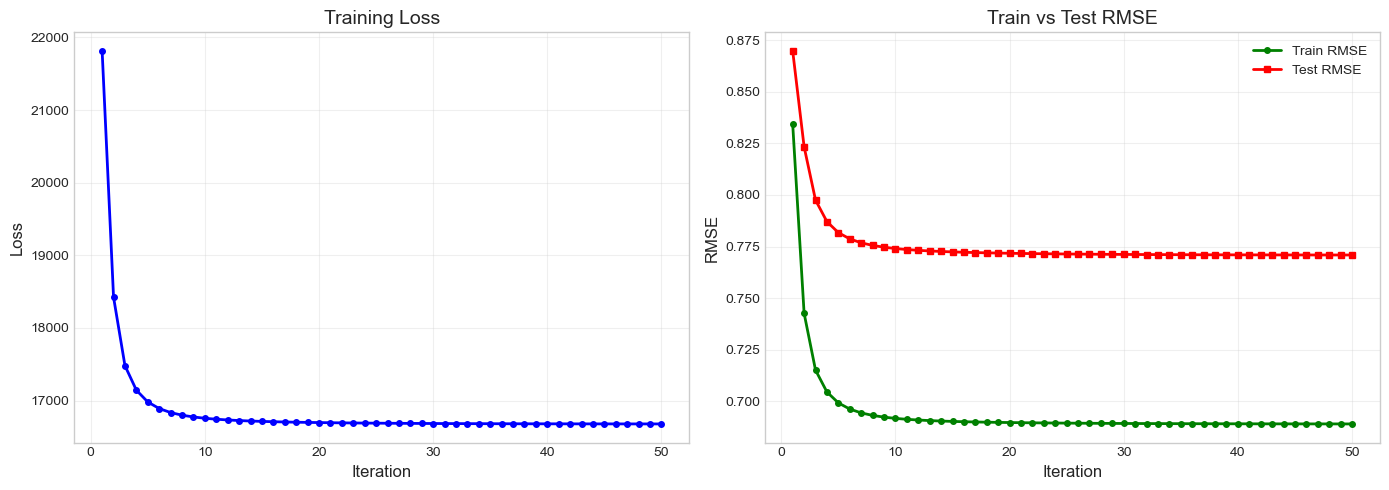

Final Train RMSE: 0.6891
Final Test RMSE:  0.7709


In [28]:
# Plot training metrics for final_model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
if hasattr(final_model, 'loss_history') and final_model.loss_history:
    iterations = range(1, len(final_model.loss_history) + 1)
    axes[0].plot(iterations, final_model.loss_history, 'b-o', linewidth=2, markersize=4)
    axes[0].set_xlabel('Iteration', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Training Loss', fontsize=14)
    axes[0].grid(True, alpha=0.3)
else:
    axes[0].text(0.5, 0.5, 'Loss history not available', ha='center', va='center', transform=axes[0].transAxes)
    axes[0].set_title('Training Loss', fontsize=14)

# RMSE plot
iterations = range(1, len(final_model.train_rmse_history) + 1)
axes[1].plot(iterations, final_model.train_rmse_history, 'g-o', linewidth=2, markersize=4, label='Train RMSE')
axes[1].plot(iterations, final_model.test_rmse_history, 'r-s', linewidth=2, markersize=4, label='Test RMSE')
axes[1].set_xlabel('Iteration', fontsize=12)
axes[1].set_ylabel('RMSE', fontsize=12)
axes[1].set_title('Train vs Test RMSE', fontsize=14)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/practical_4_final_model_training.pdf', format='pdf', dpi=150, bbox_inches='tight')
plt.show()

print(f"Final Train RMSE: {final_model.train_rmse_history[-1]:.4f}")
print(f"Final Test RMSE:  {final_model.test_rmse_history[-1]:.4f}")


## 5. Learning Curves: Overfitting/Underfitting Analysis

We plot Train and Test RMSE over iterations to observe:
- **Overfitting**: Test RMSE increases while Train RMSE decreases
- **Underfitting**: Both metrics are high and not improving

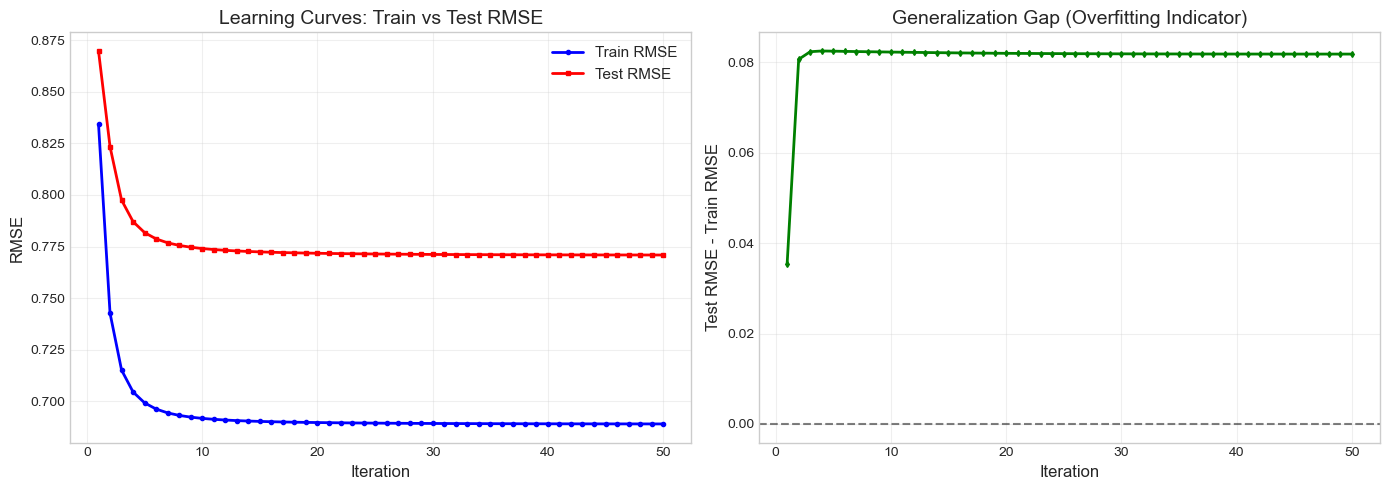

Final Train RMSE: 0.6891
Final Test RMSE:  0.7709
Generalization Gap: 0.0818


In [29]:
# Plot Learning Curves from the final model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE curves
ax1 = axes[0]
iterations = range(1, len(target_model.train_rmse_history) + 1)
ax1.plot(iterations, target_model.train_rmse_history, 'b-', linewidth=2, label='Train RMSE', marker='o', markersize=3)
ax1.plot(iterations, target_model.test_rmse_history, 'r-', linewidth=2, label='Test RMSE', marker='s', markersize=3)
ax1.set_xlabel('Iteration', fontsize=12)
ax1.set_ylabel('RMSE', fontsize=12)
ax1.set_title('Learning Curves: Train vs Test RMSE', fontsize=14)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Gap between train and test (measure of overfitting)
ax2 = axes[1]
gap = np.array(target_model.test_rmse_history) - np.array(target_model.train_rmse_history)
ax2.plot(iterations, gap, 'g-', linewidth=2, marker='d', markersize=3)
ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax2.set_xlabel('Iteration', fontsize=12)
ax2.set_ylabel('Test RMSE - Train RMSE', fontsize=12)
ax2.set_title('Generalization Gap (Overfitting Indicator)', fontsize=14)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/practical_4_learning_curves.pdf', dpi=150, bbox_inches='tight', format='pdf')
plt.show()

print(f"Final Train RMSE: {target_model.train_rmse_history[-1]:.4f}")
print(f"Final Test RMSE:  {target_model.test_rmse_history[-1]:.4f}")
print(f"Generalization Gap: {gap[-1]:.4f}")

## 6. Sanity Check: Lord of the Rings Fan

We create a synthetic user who loves "Lord of the Rings" movies and check if the model recommends other LOTR films and similar fantasy movies.

**Recommendation Scoring**: We use `score = u · v + α * b_item` where α=0.05 to downweight popularity.

In [30]:
# Find Lord of the Rings movies
movies_df = dataset.movies
lotr_movies = movies_df[movies_df['title'].str.contains('Lord of the Rings', case=False, na=False)]
print("Lord of the Rings movies found:")
print(lotr_movies[['movieId', 'title', 'genres']])

Loading movies from ..\data\ml-32m\movies.csv...
Loaded 87,585 movies
Lord of the Rings movies found:
       movieId                                              title  \
2026      2116                      Lord of the Rings, The (1978)   
4888      4993  Lord of the Rings: The Fellowship of the Ring,...   
5841      5952      Lord of the Rings: The Two Towers, The (2002)   
7029      7153  Lord of the Rings: The Return of the King, The...   
71797   231829  A Passage to Middle-earth: Making of 'Lord of ...   
79743   267392  J.R.R. Tolkien and the Birth Of "The Lord of t...   

                                     genres  
2026   Adventure|Animation|Children|Fantasy  
4888                      Adventure|Fantasy  
5841                      Adventure|Fantasy  
7029         Action|Adventure|Drama|Fantasy  
71797                           Documentary  
79743                    (no genres listed)  


In [31]:
# Get item indices for LOTR movies
lotr_movie_ids = lotr_movies['movieId'].values
item_id_to_idx = {mid: idx for idx, mid in enumerate(sorted(dataset.ratings['movieId'].unique()))}
idx_to_movie_id = {idx: mid for mid, idx in item_id_to_idx.items()}

lotr_item_indices = [item_id_to_idx[mid] for mid in lotr_movie_ids if mid in item_id_to_idx]
print(f"LOTR item indices: {lotr_item_indices}")

LOTR item indices: [2026, 4888, 5841, 7029, 69157, 76673]


In [32]:
# Create a synthetic user embedding from LOTR items
# Average the LOTR item vectors (weighted by 5-star rating)
lotr_item_vectors = target_model.item_factors[lotr_item_indices]
synthetic_user_vector = np.mean(lotr_item_vectors, axis=0)

print(f"Synthetic LOTR fan embedding shape: {synthetic_user_vector.shape}")
print(f"Synthetic user vector norm: {np.linalg.norm(synthetic_user_vector):.4f}")

Synthetic LOTR fan embedding shape: (20,)
Synthetic user vector norm: 5.4860


In [33]:
# Compute scores for all items with downweighted item bias
# score = u · v + 0.05 * b_item (downweight popularity)
BIAS_WEIGHT = 0.05
MIN_RATINGS = 100  # Filter rare items

# Get item rating counts
item_counts = dataset.ratings.groupby('item_idx').size().values

# Compute raw scores
scores = target_model.item_factors @ synthetic_user_vector + BIAS_WEIGHT * target_model.item_biases

# Filter out rare items and LOTR movies themselves
valid_mask = np.zeros(len(scores), dtype=bool)
for i in range(len(scores)):
    if i < len(item_counts) and item_counts[i] >= MIN_RATINGS and i not in lotr_item_indices:
        valid_mask[i] = True

# Get top recommendations
scores_masked = np.where(valid_mask, scores, -np.inf)
top_indices = np.argsort(scores_masked)[::-1][:20]

print("\n" + "="*80)
print("TOP 20 RECOMMENDATIONS FOR LOTR FAN (rare items filtered, bias downweighted)")
print("="*80)
for rank, idx in enumerate(top_indices, 1):
    movie_id = idx_to_movie_id.get(idx)
    if movie_id:
        title = dataset.get_movie_title(movie_id)
        n_ratings = item_counts[idx] if idx < len(item_counts) else 0
        print(f"{rank:2d}. {title[:60]:<60} (score: {scores[idx]:.3f}, ratings: {n_ratings:,})")


TOP 20 RECOMMENDATIONS FOR LOTR FAN (rare items filtered, bias downweighted)
 1. Star Wars: Episode IV - A New Hope (1977)                    (score: 25.295, ratings: 85,010)
 2. Star Wars: Episode V - The Empire Strikes Back (1980)        (score: 25.158, ratings: 72,151)
 3. Hobbit: An Unexpected Journey, The (2012)                    (score: 24.322, ratings: 16,149)
 4. Braveheart (1995)                                            (score: 24.237, ratings: 69,482)
 5. Star Wars: Episode VI - Return of the Jedi (1983)            (score: 23.497, ratings: 67,496)
 6. Blair Witch Project, The (1999)                              (score: 21.269, ratings: 22,780)
 7. Dances with Wolves (1990)                                    (score: 20.457, ratings: 46,771)
 8. Hobbit: The Desolation of Smaug, The (2013)                  (score: 19.865, ratings: 12,175)
 9. Sense and Sensibility (1995)                                 (score: 19.370, ratings: 22,251)
10. Gladiator (2000)                    

## 7. Polarizing Movies

Polarizing movies rapidly separate users - they have **long trait vectors** (|v_n| is large).

These movies can be used to quickly infer user preferences in cold-start scenarios.

In [34]:
# Compute item vector norms (polarization measure)
item_norms = np.linalg.norm(target_model.item_factors, axis=1)

# Get rating counts per item for filtering
item_rating_counts = dataset.ratings.groupby('item_idx').size().values

# Create DataFrame with polarization info
polarization_df = pd.DataFrame({
    'item_idx': range(len(item_norms)),
    'norm': item_norms,
    'n_ratings': [item_rating_counts[i] if i < len(item_rating_counts) else 0 for i in range(len(item_norms))]
})

# Filter for items with enough ratings
polarization_df = polarization_df[polarization_df['n_ratings'] >= MIN_RATINGS]

# Sort by norm (most polarizing first)
polarization_df = polarization_df.sort_values('norm', ascending=False)

# Add movie titles
polarization_df['movie_id'] = polarization_df['item_idx'].map(idx_to_movie_id)
polarization_df['title'] = polarization_df['movie_id'].apply(lambda x: dataset.get_movie_title(x) if x else 'Unknown')

print("\n" + "="*80)
print("TOP 20 MOST POLARIZING MOVIES (highest |v_n|)")
print("="*80)
for i, row in polarization_df.head(20).iterrows():
    print(f"{row['title'][:55]:<55} | norm: {row['norm']:.3f} | ratings: {row['n_ratings']:,}")


TOP 20 MOST POLARIZING MOVIES (highest |v_n|)
Lord of the Rings: The Return of the King, The (2003)   | norm: 10.488 | ratings: 67,449
Lord of the Rings: The Fellowship of the Ring, The (200 | norm: 10.460 | ratings: 73,122
Lord of the Rings: The Two Towers, The (2002)           | norm: 10.282 | ratings: 67,463
Star Wars: Episode IV - A New Hope (1977)               | norm: 9.517 | ratings: 85,010
Pulp Fiction (1994)                                     | norm: 9.311 | ratings: 98,409
Dumb & Dumber (Dumb and Dumber) (1994)                  | norm: 9.034 | ratings: 36,802
Star Wars: Episode V - The Empire Strikes Back (1980)   | norm: 9.003 | ratings: 72,151
Star Wars: Episode VI - Return of the Jedi (1983)       | norm: 8.827 | ratings: 67,496
Natural Born Killers (1994)                             | norm: 8.711 | ratings: 26,472
Star Wars: Episode I - The Phantom Menace (1999)        | norm: 8.352 | ratings: 37,973
Kill Bill: Vol. 1 (2003)                                | norm: 8.308 

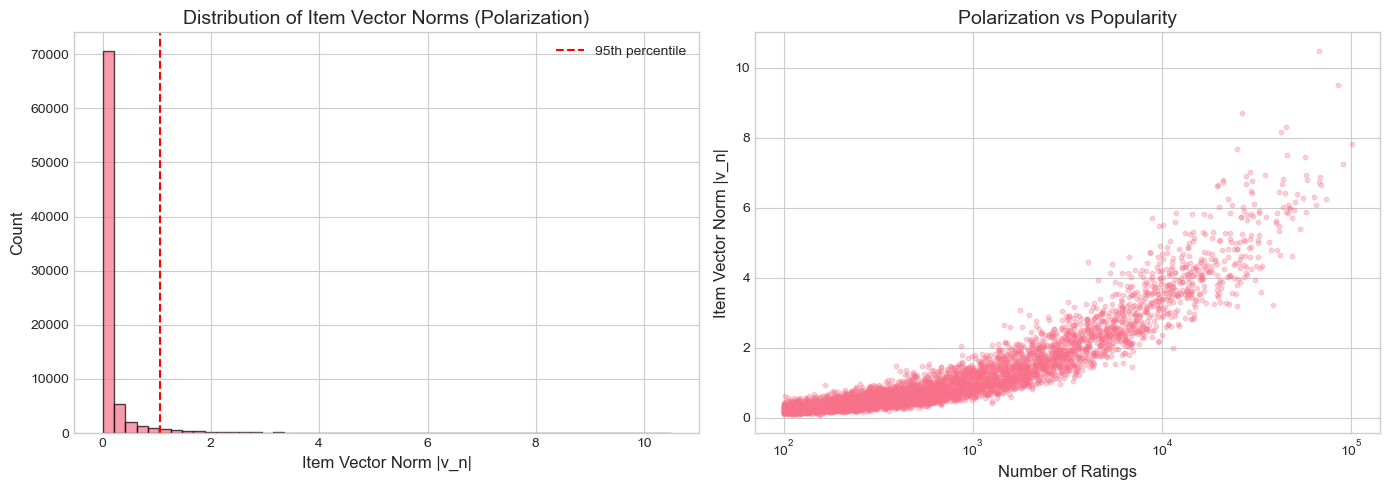


Polarization Statistics:
  Mean |v_n|: 0.2100
  Std |v_n|:  0.6024
  Max |v_n|:  10.4882


In [35]:
# Visualize polarization distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of item norms
ax1 = axes[0]
ax1.hist(item_norms, bins=50, edgecolor='black', alpha=0.7)
ax1.axvline(x=np.percentile(item_norms, 95), color='red', linestyle='--', label='95th percentile')
ax1.set_xlabel('Item Vector Norm |v_n|', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.set_title('Distribution of Item Vector Norms (Polarization)', fontsize=14)
ax1.legend()

# Scatter: norm vs rating count
ax2 = axes[1]
sample_df = polarization_df.sample(min(5000, len(polarization_df)), random_state=42)
ax2.scatter(sample_df['n_ratings'], sample_df['norm'], alpha=0.3, s=10)
ax2.set_xlabel('Number of Ratings', fontsize=12)
ax2.set_ylabel('Item Vector Norm |v_n|', fontsize=12)
ax2.set_title('Polarization vs Popularity', fontsize=14)
ax2.set_xscale('log')

plt.tight_layout()
plt.savefig('../figures/practical_4_polarization.pdf', dpi=150, bbox_inches='tight', format='pdf')
plt.show()

print(f"\nPolarization Statistics:")
print(f"  Mean |v_n|: {np.mean(item_norms):.4f}")
print(f"  Std |v_n|:  {np.std(item_norms):.4f}")
print(f"  Max |v_n|:  {np.max(item_norms):.4f}")

## 8. Embedding Visualization using PCA

We project the K-dimensional item embeddings to 2D using PCA to visualize the learned representation space.

In [36]:
# PCA on item factors
pca = PCA(n_components=2)
item_factors_2d = pca.fit_transform(target_model.item_factors)

print(f"PCA Explained Variance Ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_)*100:.1f}%")

PCA Explained Variance Ratio: [0.13806698 0.08406576]
Total variance explained: 22.2%


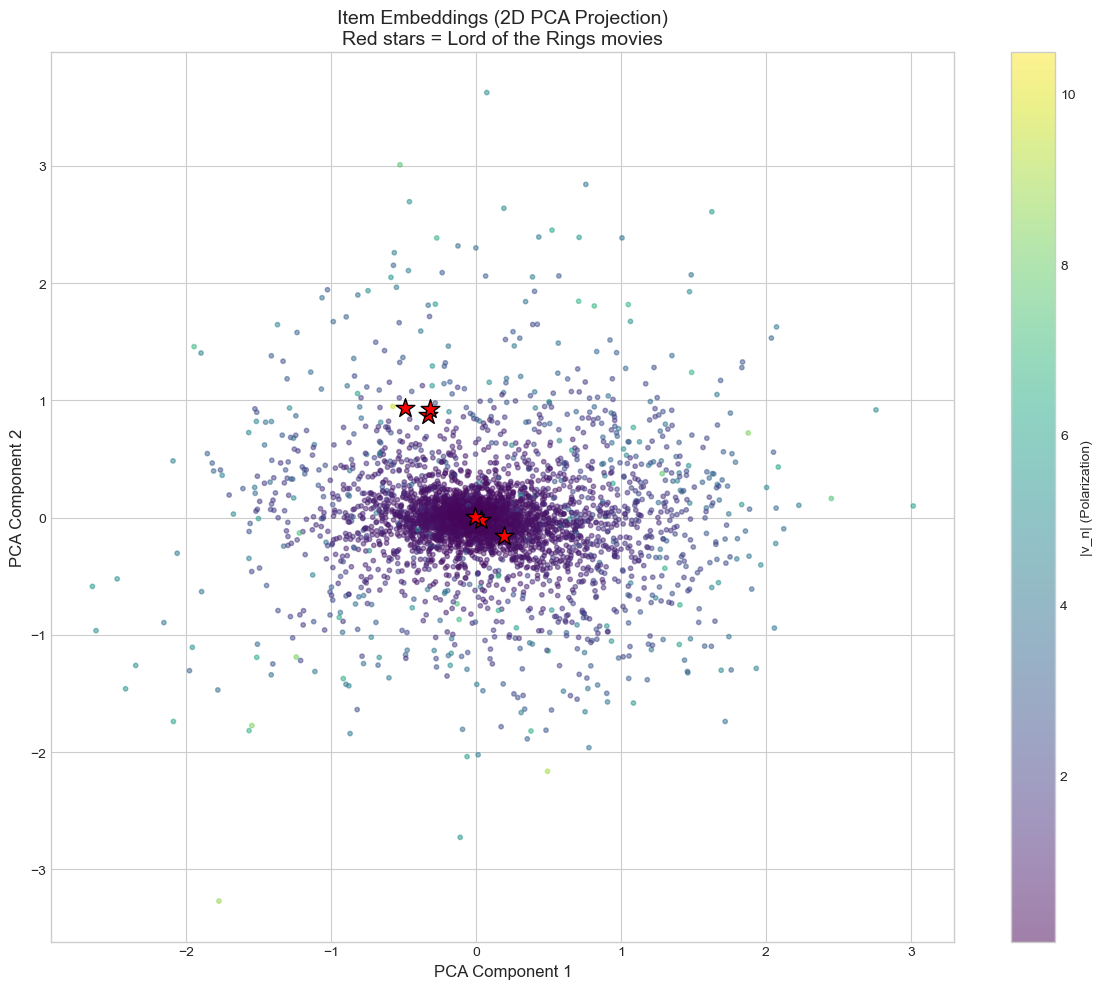

In [37]:
# Sample items for visualization (to avoid overcrowding)
np.random.seed(42)
sample_size = 5000

# Filter to items with enough ratings
valid_items = [i for i in range(len(item_norms)) if i < len(item_rating_counts) and item_rating_counts[i] >= 50]
sample_indices = np.random.choice(valid_items, min(sample_size, len(valid_items)), replace=False)

# Get colors based on norm (polarization)
sample_norms = item_norms[sample_indices]

fig, ax = plt.subplots(figsize=(12, 10))
scatter = ax.scatter(
    item_factors_2d[sample_indices, 0],
    item_factors_2d[sample_indices, 1],
    c=sample_norms,
    cmap='viridis',
    alpha=0.5,
    s=10
)
plt.colorbar(scatter, label='|v_n| (Polarization)')

# Highlight LOTR movies
for idx in lotr_item_indices:
    ax.scatter(
        item_factors_2d[idx, 0],
        item_factors_2d[idx, 1],
        c='red',
        s=200,
        marker='*',
        edgecolors='black',
        linewidths=1,
        zorder=5
    )

ax.set_xlabel('PCA Component 1', fontsize=12)
ax.set_ylabel('PCA Component 2', fontsize=12)
ax.set_title('Item Embeddings (2D PCA Projection)\nRed stars = Lord of the Rings movies', fontsize=14)

plt.tight_layout()
plt.savefig('../figures/practical_4_pca_embeddings.pdf', dpi=150, bbox_inches='tight', format='pdf')
plt.show()

In [38]:
# Visualize genre clusters using PCA
# Extract genre for each sampled item
def get_primary_genre(movie_id):
    """Get the primary (first) genre of a movie."""
    row = movies_df[movies_df['movieId'] == movie_id]
    if len(row) == 0:
        return 'Unknown'
    genres = row['genres'].values[0]
    if pd.isna(genres) or genres == '(no genres listed)':
        return 'Unknown'
    return genres.split('|')[0]

# Get genres for sampled items
sample_movie_ids = [idx_to_movie_id.get(i) for i in sample_indices]
sample_genres = [get_primary_genre(mid) if mid else 'Unknown' for mid in sample_movie_ids]

# Get top genres
from collections import Counter
genre_counts = Counter(sample_genres)
top_genres = [g for g, _ in genre_counts.most_common(8) if g != 'Unknown']

print(f"Top genres in sample: {top_genres}")

Top genres in sample: ['Comedy', 'Drama', 'Action', 'Horror', 'Adventure', 'Crime', 'Documentary', 'Animation']


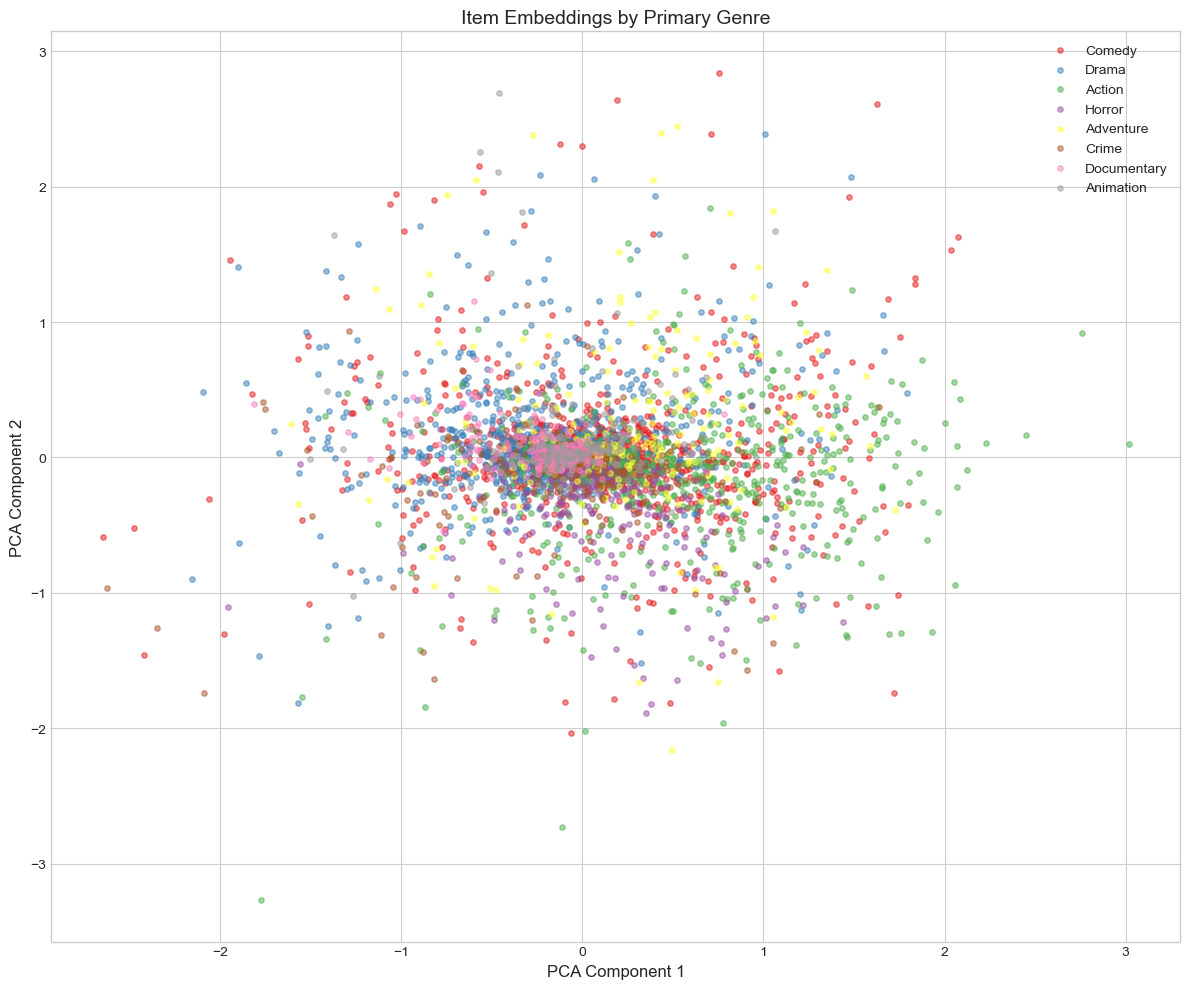

In [39]:
# Plot by genre
fig, ax = plt.subplots(figsize=(12, 10))

colors = plt.cm.Set1(np.linspace(0, 1, len(top_genres)))
genre_to_color = {g: c for g, c in zip(top_genres, colors)}

for genre in top_genres:
    mask = np.array([g == genre for g in sample_genres])
    ax.scatter(
        item_factors_2d[sample_indices[mask], 0],
        item_factors_2d[sample_indices[mask], 1],
        c=[genre_to_color[genre]],
        label=genre,
        alpha=0.5,
        s=15
    )

ax.legend(loc='best', fontsize=10)
ax.set_xlabel('PCA Component 1', fontsize=12)
ax.set_ylabel('PCA Component 2', fontsize=12)
ax.set_title('Item Embeddings by Primary Genre', fontsize=14)

plt.tight_layout()
plt.savefig('../figures/practical_4_pca_genres.pdf', dpi=150, bbox_inches='tight', format='pdf')
plt.show()

## 9. Summary & Conclusions

### Key Observations:

1. **Overfitting Analysis**: The gap between Train and Test RMSE indicates the degree of overfitting.

2. **LOTR Sanity Check**: Recommendations for a Lord of the Rings fan should include other fantasy/adventure films.

3. **Polarizing Movies**: Movies with high |v_n| are polarizing - they quickly separate user preferences.

4. **PCA Visualization**: The embedding space shows semantic clusters where similar movies are grouped together.

Finding selected movies...
  Star Wars: found 3 movies
  Harry Potter: found 3 movies
  Matrix: found 3 movies
  Toy Story: found 3 movies
  Godfather: found 3 movies


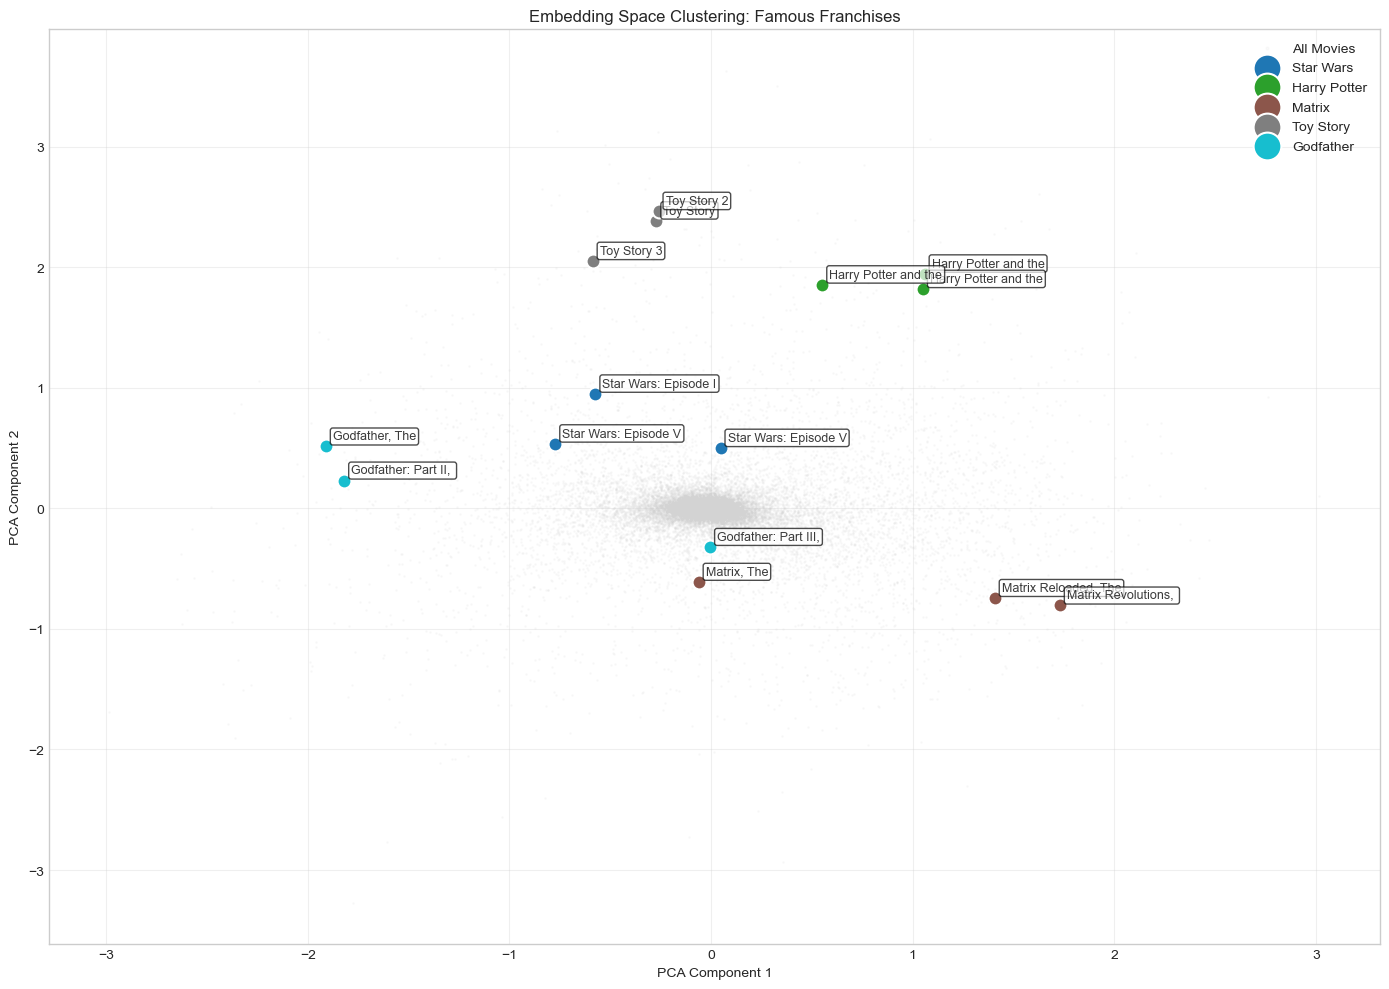

In [40]:
# Visualize specific movie clusters
# We select a few famous franchises to demonstrate clustering
selected_franchises = {
    'Star Wars': ['Star Wars: Episode IV', 'Star Wars: Episode V', 'Star Wars: Episode VI'],
    'Harry Potter': ['Harry Potter and the Sorcerer', 'Harry Potter and the Chamber', 'Harry Potter and the Prisoner'],
    'Matrix': ['Matrix, The', 'Matrix Reloaded', 'Matrix Revolutions'],
    'Toy Story': ['Toy Story (1995)', 'Toy Story 2', 'Toy Story 3'],
    'Godfather': ['Godfather, The (1972)', 'Godfather: Part II', 'Godfather: Part III']
}

# Find indices for these movies
franchise_indices = {}
all_selected_indices = []

print("Finding selected movies...")
for franchise, titles in selected_franchises.items():
    indices = []
    for title_part in titles:
        # Search for movie
        matches = movies_df[movies_df['title'].str.contains(title_part, case=False, regex=False)]
        if not matches.empty:
            # Get the first match
            movie_id = matches.iloc[0]['movieId']
            if movie_id in item_id_to_idx:
                idx = item_id_to_idx[movie_id]
                indices.append((idx, matches.iloc[0]['title']))
                all_selected_indices.append(idx)
    franchise_indices[franchise] = indices
    print(f"  {franchise}: found {len(indices)} movies")

# Re-run PCA on all items if not already done (or use existing)
if 'item_factors_2d' not in locals():
    pca = PCA(n_components=2)
    item_factors_2d = pca.fit_transform(target_model.item_factors)

# Plot
fig, ax = plt.subplots(figsize=(14, 10))

# Plot background density (all items)
ax.scatter(
    item_factors_2d[:, 0],
    item_factors_2d[:, 1],
    c='lightgray',
    alpha=0.1,
    s=1,
    label='All Movies'
)

# Plot selected franchises
colors = plt.cm.tab10(np.linspace(0, 1, len(selected_franchises)))

for (franchise, movies), color in zip(franchise_indices.items(), colors):
    if not movies: 
        continue
        
    indices = [m[0] for m in movies]
    titles = [m[1] for m in movies]
    
    # Plot points
    ax.scatter(
        item_factors_2d[indices, 0],
        item_factors_2d[indices, 1],
        c=[color],
        label=franchise,
        s=100,
        edgecolors='white',
        linewidth=1.5
    )
    
    # Add labels
    for idx, title in zip(indices, titles):
        short_title = title.split('(')[0].strip()[:20]
        ax.annotate(
            short_title,
            (item_factors_2d[idx, 0], item_factors_2d[idx, 1]),
            xytext=(5, 5), textcoords='offset points',
            fontsize=9,
            alpha=0.9,
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7)
        )

ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_title('Embedding Space Clustering: Famous Franchises')
ax.legend(markerscale=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/practical_4_clusters.pdf', dpi=150, format='pdf')
plt.show()

In [41]:
# Final model summary
print("="*60)
print("PRACTICAL 4 - MODEL SUMMARY")
print("="*60)
print(f"Dataset: {DATASET_NAME}")
print(f"Train ratings: {len(train_data[2]):,}")
print(f"Test ratings:  {len(test_data[2]):,}")
print(f"")
print(f"Model Parameters:")
print(f"  K (latent dim): {target_model.K}")
print(f"  lambda: {target_model.lambda_:.6f}")
print(f"  tau: {target_model.tau:.6f}")
print(f"  gamma: {target_model.gamma:.6f}")
print(f"")
print(f"Final Performance:")
print(f"  Train RMSE: {target_model.train_rmse_history[-1]:.4f}")
print(f"  Test RMSE:  {target_model.test_rmse_history[-1]:.4f}")
print(f"  Gap:        {target_model.test_rmse_history[-1] - target_model.train_rmse_history[-1]:.4f}")

PRACTICAL 4 - MODEL SUMMARY
Dataset: ml-32m
Train ratings: 25,600,163
Test ratings:  6,400,041

Model Parameters:
  K (latent dim): 20
  lambda: 0.002352
  tau: 0.063102
  gamma: 0.013236

Final Performance:
  Train RMSE: 0.6891
  Test RMSE:  0.7709
  Gap:        0.0818
